In [1]:
# =====================================================
# Notebook 5
# Cell 1 - Install Packages
# =====================================================

!pip -q install -U \
transformers \
datasets \
sentencepiece \
accelerate \
rouge-score \
sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 90.4 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.9 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 w

In [2]:
# =====================================================
# Cell 2 - Imports
# =====================================================

import os
import gc
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

import torch

from sklearn.model_selection import train_test_split

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)

warnings.filterwarnings("ignore")

2026-06-28 16:17:53.210803: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782663473.447765      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782663473.511510      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782663474.010507      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782663474.010547      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782663474.010549      58 computation_placer.cc:177] computation placer alr

In [3]:
# =====================================================
# Cell 3 - Config
# =====================================================

SEED = 42

MODEL_NAME = "google/mt5-small"

MAX_INPUT_LENGTH = 128
MAX_TARGET_LENGTH = 128

TRAIN_BATCH_SIZE = 8
VALID_BATCH_SIZE = 8

GRADIENT_ACCUMULATION = 2

LEARNING_RATE = 3e-4

WEIGHT_DECAY = 0.01

NUM_EPOCHS = 5

OUTPUT_DIR = "./mt5_output"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("Config loaded.")

Config loaded.


In [4]:
# =====================================================
# Cell 4 - Reproducibility
# =====================================================

def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    tf.random.set_seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

print("Seed =", SEED)

Seed = 42


In [5]:
# =====================================================
# Cell 5 - Load Dataset
# =====================================================

import pandas as pd

df1 = pd.read_parquet(
    "/kaggle/input/models/trngtnhng/datbilstm/keras/default/4/train-00000-of-00002.parquet"
)

df2 = pd.read_parquet(
    "/kaggle/input/models/trngtnhng/datbilstm/keras/default/4/train-00001-of-00002.parquet"
)

df = pd.concat(
    [df1, df2],
    ignore_index=True
)

df = df[["question", "answer"]]

df = df.dropna()

df["question"] = df["question"].astype(str)

df["answer"] = df["answer"].astype(str)

print(df.shape)

df.head()

(750169, 2)


,question,answer
0,Tôi nghĩ việc tạo ra một kế hoạch kinh doanh v...,Ý tưởng tuyệt vời! Một kế hoạch kinh doanh đón...
1,"Hiện tại thì chưa, nhưng tôi chắc chắn có thể ...",Điều đó thật tuyệt! Việc sử dụng các nguồn lực...
2,"Vâng, tài trợ là một khía cạnh quan trọng. Tôi...",Điểm tuyệt vời! Nguồn tài trợ thực sự là một v...
3,Cảm ơn. Sự hướng dẫn và động viên của bạn có ý...,Không có gì! Tôi rất vui khi biết rằng bạn cảm...
4,Cảm ơn. Tôi sẽ ghi nhớ lời nói của bạn và tiếp...,"Đó chính là tinh thần! Hãy nhớ rằng, ước mơ sẽ..."


In [6]:
# =====================================================
# Cell 6 - Load Router
# =====================================================

ROUTER_PATH = "/kaggle/input/models/trngtnhng/datbilstm/keras/default/4/03_bilstm_export.keras"

router = tf.keras.models.load_model(
    ROUTER_PATH,
    compile=False
)

router.summary()

print("Router loaded.")

I0000 00:00:1782663555.029276      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782663555.035250      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "BiLSTM_SafetyRouter_Export"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)         │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 128)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiLSTM_SafetyRouter             │ (None, 5)              │     4,136,709 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,136,709 (15.78 MB)

 Trainable params: 4,136,709 (15.78 MB)

 Non-trainable params: 0 (0.00 B)

Router loaded.


In [13]:
# =====================================================
# Cell 7 - Predict Route (Keras3 Safe Version)
# =====================================================

LABEL_NAMES = [
    "normal_support",
    "school_stress",
    "relationship_issue",
    "self_care",
    "high_risk",
]

questions = df["question"].fillna("").astype(str).tolist()

batch_size = 256

route_ids = []

print(f"Total samples: {len(questions):,}")

for start in range(0, len(questions), batch_size):

    batch = questions[start:start + batch_size]

    batch = tf.constant(batch, dtype=tf.string)

    batch = tf.expand_dims(batch, axis=-1)

    logits = router(batch, training=False)

    route_ids.extend(
        np.argmax(
            logits.numpy(),
            axis=1
        )
    )

    if start % 50000 == 0:
        print(f"{start:,}/{len(questions):,}")

df["route"] = [
    LABEL_NAMES[i]
    for i in route_ids
]

print(df["route"].value_counts())

gc.collect()

Total samples: 750,169
0/750,169
route
normal_support        377135
self_care             226035
relationship_issue    120000
school_stress          24638
high_risk               2361
Name: count, dtype: int64


597

In [14]:
# =====================================================
# Cell 8 - Remove High Risk
# =====================================================

df = df[df["route"] != "high_risk"].reset_index(drop=True)

print(df.shape)

print(df["route"].value_counts())

(747808, 3)
route
normal_support        377135
self_care             226035
relationship_issue    120000
school_stress          24638
Name: count, dtype: int64


In [15]:
# =====================================================
# Cell 9 - Balance Dataset
# =====================================================

TARGET_PER_ROUTE = 25000

balanced_df = (
    df.groupby("route", group_keys=False)
      .apply(
          lambda x: x.sample(
              min(len(x), TARGET_PER_ROUTE),
              random_state=42
          )
      )
      .reset_index(drop=True)
)

print(balanced_df.shape)

print(balanced_df.route.value_counts())

(99638, 3)
route
normal_support        25000
relationship_issue    25000
self_care             25000
school_stress         24638
Name: count, dtype: int64


In [16]:
# =====================================================
# Cell 10 - Train / Valid / Test
# =====================================================

train_df, temp_df = train_test_split(

    balanced_df,

    test_size=0.2,

    random_state=42,

    stratify=balanced_df["route"]

)

valid_df, test_df = train_test_split(

    temp_df,

    test_size=0.5,

    random_state=42,

    stratify=temp_df["route"]

)

print(train_df.shape)

print(valid_df.shape)

print(test_df.shape)

(79710, 3)
(9964, 3)
(9964, 3)


In [17]:
# =====================================================
# Cell 11 - Prompt Engineering
# =====================================================

def build_prompt(route, question):

    return f"""Bạn là chatbot tư vấn tâm lý học đường.

Danh mục: {route}

Học sinh:

{question}

Trả lời:"""


for data in [train_df, valid_df, test_df]:

    data["input_text"] = data.apply(

        lambda x: build_prompt(

            x["route"],

            x["question"]

        ),

        axis=1

    )

    data["target_text"] = data["answer"]

In [18]:
# =====================================================
# Cell 12 - Save CSV
# =====================================================

train_df.to_csv(

    "mt5_train.csv",

    index=False,

    encoding="utf-8-sig"

)

valid_df.to_csv(

    "mt5_valid.csv",

    index=False,

    encoding="utf-8-sig"

)

test_df.to_csv(

    "mt5_test.csv",

    index=False,

    encoding="utf-8-sig"

)

print("Saved.")

Saved.


In [19]:
# =====================================================
# Cell 13 - HF Dataset
# =====================================================

from datasets import Dataset

train_dataset = Dataset.from_pandas(

    train_df[
        ["input_text", "target_text"]
    ],

    preserve_index=False

)

valid_dataset = Dataset.from_pandas(

    valid_df[
        ["input_text", "target_text"]
    ],

    preserve_index=False

)

test_dataset = Dataset.from_pandas(

    test_df[
        ["input_text", "target_text"]
    ],

    preserve_index=False

)

print(train_dataset)

print(valid_dataset)

print(test_dataset)

Dataset({
    features: ['input_text', 'target_text'],
    num_rows: 79710
})
Dataset({
    features: ['input_text', 'target_text'],
    num_rows: 9964
})
Dataset({
    features: ['input_text', 'target_text'],
    num_rows: 9964
})


In [20]:
# =====================================================
# Cell 14 - Load mT5
# =====================================================

from transformers import AutoTokenizer
from transformers import AutoModelForSeq2SeqLM

MODEL_NAME = "google/mt5-small"

print("Loading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False
)

print("Loading model...")

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME
)

print("Done.")

Loading tokenizer...


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Done.


In [21]:
# =====================================================
# Cell 15 - Tokenization
# =====================================================

MAX_INPUT_LENGTH = 128
MAX_TARGET_LENGTH = 128


def preprocess(example):

    model_inputs = tokenizer(

        example["input_text"],

        max_length=MAX_INPUT_LENGTH,

        truncation=True,

        padding="max_length"

    )

    labels = tokenizer(

        text_target=example["target_text"],

        max_length=MAX_TARGET_LENGTH,

        truncation=True,

        padding="max_length"

    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

In [22]:
# =====================================================
# Cell 16 - Tokenize Dataset
# =====================================================

train_tokenized = train_dataset.map(

    preprocess,

    batched=True,

    remove_columns=train_dataset.column_names

)

valid_tokenized = valid_dataset.map(

    preprocess,

    batched=True,

    remove_columns=valid_dataset.column_names

)

test_tokenized = test_dataset.map(

    preprocess,

    batched=True,

    remove_columns=test_dataset.column_names

)

print(train_tokenized)

Map:   0%|          | 0/79710 [00:00<?, ? examples/s]

Map:   0%|          | 0/9964 [00:00<?, ? examples/s]

Map:   0%|          | 0/9964 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 79710
})


In [23]:
# =====================================================
# Cell 17 - Data Collator
# =====================================================

from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(

    tokenizer=tokenizer,

    model=model

)

print("Done.")

Done.


In [29]:
# =====================================================
# Cell 18 - Compute Metrics
# =====================================================

from rouge_score import rouge_scorer
import numpy as np

scorer = rouge_scorer.RougeScorer(
    ["rouge1","rouge2","rougeL"],
    use_stemmer=False
)

def compute_metrics(eval_preds):

    preds, labels = eval_preds

    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = tokenizer.batch_decode(
        preds,
        skip_special_tokens=True
    )

    labels = np.where(
        labels != -100,
        labels,
        tokenizer.pad_token_id
    )

    decoded_labels = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True
    )

    rouge1 = []
    rouge2 = []
    rougeL = []

    for pred, label in zip(decoded_preds, decoded_labels):

        score = scorer.score(label, pred)

        rouge1.append(score["rouge1"].fmeasure)
        rouge2.append(score["rouge2"].fmeasure)
        rougeL.append(score["rougeL"].fmeasure)

    return {

        "rouge1": float(np.mean(rouge1)),
        "rouge2": float(np.mean(rouge2)),
        "rougeL": float(np.mean(rougeL))

    }

In [30]:
# =====================================================
# Cell 19 - Training Arguments
# =====================================================

from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(

    output_dir="./mt5_output",

    do_train=True,

    do_eval=True,

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=3e-4,

    weight_decay=0.01,

    warmup_steps=500,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    gradient_accumulation_steps=2,

    num_train_epochs=5,

    logging_steps=100,

    save_total_limit=2,

    predict_with_generate=True,

    generation_max_length=128,

    load_best_model_at_end=True,

    metric_for_best_model="rougeL",

    greater_is_better=True,

    fp16=torch.cuda.is_available(),

    report_to="none",

    seed=42

)

print(training_args)

Seq2SeqTrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=True,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH

In [31]:
# =====================================================
# Cell 20 - Trainer
# =====================================================

from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(

    model=model,

    args=training_args,

    train_dataset=train_tokenized,

    eval_dataset=valid_tokenized,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics,

)

print("Trainer Ready!")

Trainer Ready!


In [32]:
# =====================================================
# Cell 21 - Train mT5
# =====================================================

train_result = trainer.train()

print("=" * 60)
print("Training Finished!")
print("=" * 60)

trainer.save_model("./mt5_output/best_model")
tokenizer.save_pretrained("./mt5_output/best_model")

print("Model saved.")

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,4.177032,0.881860,0.635160,0.243670,0.356828
2,3.587991,0.779351,0.649302,0.263579,0.370550
3,3.352734,0.735075,0.654620,0.272731,0.377222
4,3.205998,0.709982,0.654235,0.275742,0.377410
5,3.172637,0.701445,0.654187,0.277206,0.378985


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Training Finished!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved.


In [33]:
# =====================================================
# Cell 22 - Validation Evaluation
# =====================================================

metrics = trainer.evaluate()

print(metrics)

Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel
3.172637,0.701445,5,0.654187,0.277206,0.378985


{'eval_loss': 0.7014448046684265, 'eval_rouge1': 0.6541873321961089, 'eval_rouge2': 0.2772063739980555, 'eval_rougeL': 0.37898526025421186}


In [34]:
# =====================================================
# Cell 23 - Test Evaluation
# =====================================================

test_metrics = trainer.evaluate(test_tokenized)

print("=" * 60)
print("Test Metrics")
print("=" * 60)

for k, v in test_metrics.items():
    print(f"{k:<25} : {v}")

Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel
3.172637,0.703109,5,0.653379,0.277256,0.379153


Test Metrics
eval_loss                 : 0.7031094431877136
eval_rouge1               : 0.6533788127917664
eval_rouge2               : 0.2772559208901932
eval_rougeL               : 0.3791527549528438


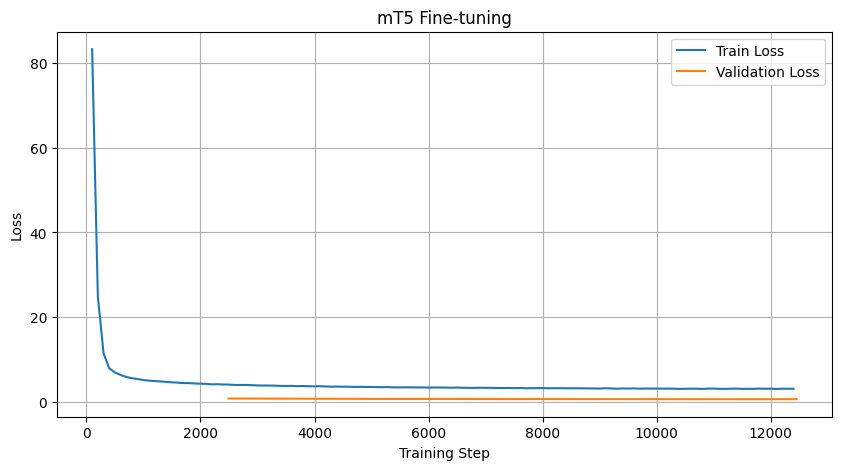

In [35]:
# =====================================================
# Cell 24 - Learning Curve
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)

history.head()

plt.figure(figsize=(10,5))

train_loss = history.dropna(subset=["loss"])

plt.plot(
    train_loss["step"],
    train_loss["loss"],
    label="Train Loss"
)

if "eval_loss" in history.columns:

    eval_loss = history.dropna(subset=["eval_loss"])

    plt.plot(
        eval_loss["step"],
        eval_loss["eval_loss"],
        label="Validation Loss"
    )

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("mT5 Fine-tuning")

plt.grid(True)

plt.legend()

plt.show()

In [36]:
# =====================================================
# Cell 25 - Demo Inference
# =====================================================

def generate_answer(question, route):

    prompt = f"""Bạn là chatbot tư vấn tâm lý học đường.

Danh mục: {route}

Học sinh:

{question}

Trả lời:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}
        model.cuda()

    output = model.generate(
        **inputs,
        max_length=128,
        num_beams=4,
        early_stopping=True
    )

    return tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

In [37]:
# =====================================================
# Cell 26 - Save Metrics
# =====================================================

import pandas as pd

metric_df = pd.DataFrame([test_metrics])

metric_df.to_csv(
    "mt5_metrics.csv",
    index=False
)

metric_df

,eval_loss,eval_rouge1,eval_rouge2,eval_rougeL
0,0.703109,0.653379,0.277256,0.379153


In [38]:
# =====================================================
# Cell 27 - Save Final Model
# =====================================================

trainer.save_model("mt5_final")

tokenizer.save_pretrained("mt5_final")

print("Saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved!


In [39]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)

history.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_rouge1,eval_rouge2,eval_rougeL,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,83.188330,760.767212,0.000059,0.040145,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,24.957876,22.802715,0.000119,0.080289,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11.563870,3.556004,0.000179,0.120434,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7.985657,32.192421,0.000239,0.160578,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7.016954,2.376161,0.000299,0.200723,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


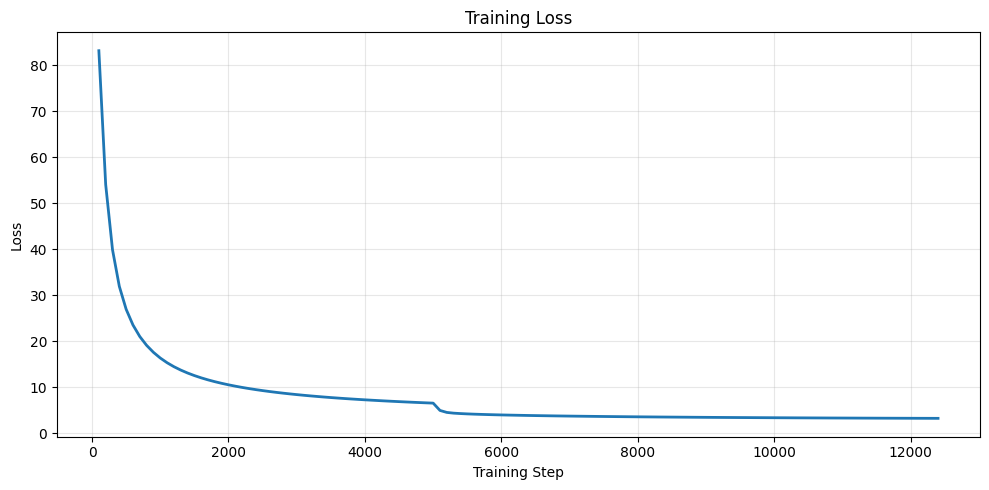

In [40]:
# ============================================
# Figure 1 - Training Loss
# ============================================

train_loss = history.dropna(subset=["loss"]).copy()

# Moving Average
train_loss["smooth"] = train_loss["loss"].rolling(
    window=50,
    min_periods=1
).mean()

plt.figure(figsize=(10,5))

plt.plot(
    train_loss["step"],
    train_loss["smooth"],
    linewidth=2
)

plt.title("Training Loss")

plt.xlabel("Training Step")

plt.ylabel("Loss")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figure_train_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

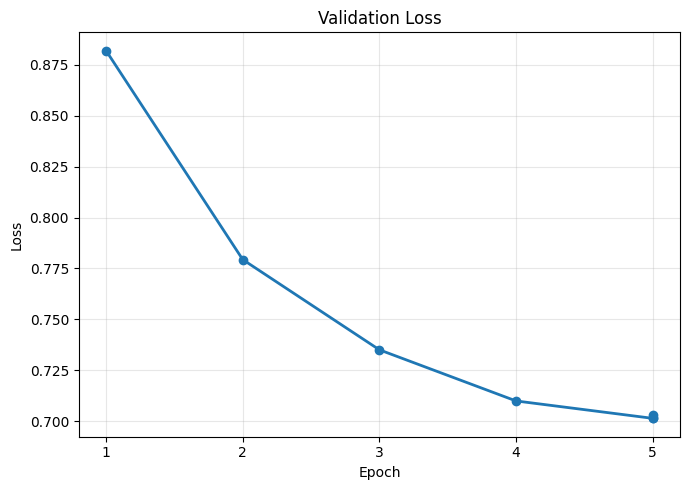

In [41]:
# ============================================
# Figure 2 - Validation Loss
# ============================================

eval_loss = history.dropna(subset=["eval_loss"])

plt.figure(figsize=(7,5))

plt.plot(
    eval_loss["epoch"],
    eval_loss["eval_loss"],
    marker="o",
    linewidth=2
)

plt.title("Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.xticks(range(1,6))

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figure_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

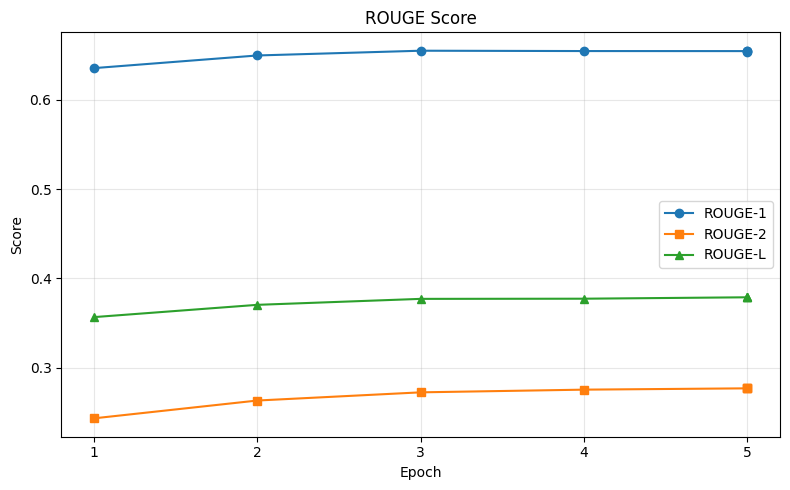

In [42]:
# ============================================
# Figure 3 - ROUGE
# ============================================

rouge = history.dropna(subset=["eval_rouge1"])

plt.figure(figsize=(8,5))

plt.plot(
    rouge["epoch"],
    rouge["eval_rouge1"],
    marker="o",
    label="ROUGE-1"
)

plt.plot(
    rouge["epoch"],
    rouge["eval_rouge2"],
    marker="s",
    label="ROUGE-2"
)

plt.plot(
    rouge["epoch"],
    rouge["eval_rougeL"],
    marker="^",
    label="ROUGE-L"
)

plt.title("ROUGE Score")

plt.xlabel("Epoch")

plt.ylabel("Score")

plt.xticks(range(1,6))

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "figure_rouge.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

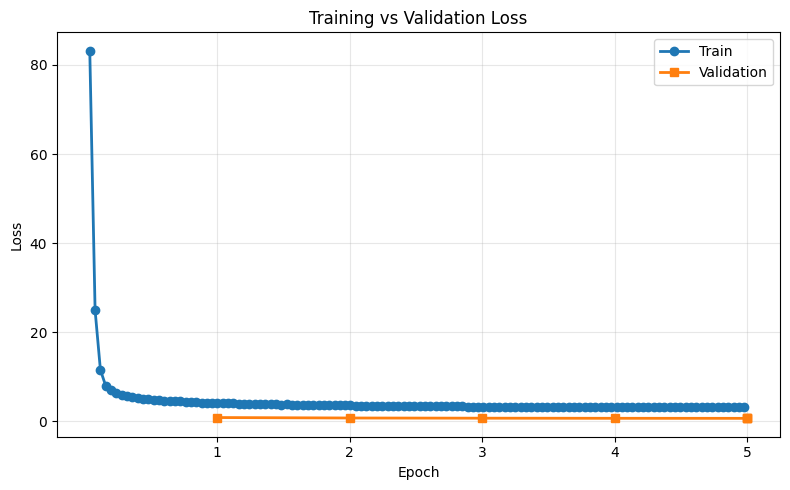

In [44]:
# Train loss theo epoch lấy từ log cuối mỗi epoch
train_epoch = (
    history.dropna(subset=["loss"])
           .groupby("epoch", as_index=False)
           .last()[["epoch", "loss"]]
           .rename(columns={"loss": "train_loss"})
)

eval_loss = history.dropna(subset=["eval_loss"])

plt.figure(figsize=(8,5))

plt.plot(
    train_epoch["epoch"],
    train_epoch["train_loss"],
    marker="o",
    linewidth=2,
    label="Train"
)

plt.plot(
    eval_loss["epoch"],
    eval_loss["eval_loss"],
    marker="s",
    linewidth=2,
    label="Validation"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1,6))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "figure_train_val.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()